## Task A - Dataset Preparation
Name: Janani K



Roll no: 24BAD039

In [ ]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_path = "/content/brain_tumor"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")
print(os.listdir(extract_path))

Dataset extracted!
['Testing', 'Training']


In [ ]:
import os

for root, dirs, files in os.walk("/content/brain_tumor"):
    if "Training" in dirs and "Testing" in dirs:
        dataset_path = root
        break

print("Dataset path:", dataset_path)

Training:
['pituitary_tumor', 'meningioma_tumor', 'glioma_tumor', 'no_tumor']

Testing:
['pituitary_tumor', 'meningioma_tumor', 'glioma_tumor', 'no_tumor']


In [ ]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

print("Training path:", train_path)
print("Testing path:", test_path)

/content/brain_tumor/Training
/content/brain_tumor/Testing


In [ ]:
print("Training classes:")
print(os.listdir(train_path))

print("\nTesting classes:")
print(os.listdir(test_path))

In [ ]:
print("========== TRAINING DATA ==========")

for class_name in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count} images")


print("\n========== TESTING DATA ==========")

for class_name in sorted(os.listdir(test_path)):
    class_path = os.path.join(test_path, class_name)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count} images")

========== TRAINING DATA ==========
glioma_tumor: 826 images
meningioma_tumor: 822 images
no_tumor: 395 images
pituitary_tumor: 827 images

========== TESTING DATA ==========
glioma_tumor: 100 images
meningioma_tumor: 115 images
no_tumor: 105 images
pituitary_tumor: 74 images


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.


In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2870 files belonging to 4 classes.
Using 574 files for validation.


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 394 files belonging to 4 classes.


In [ ]:
class_names = train_dataset.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Number of classes: 4


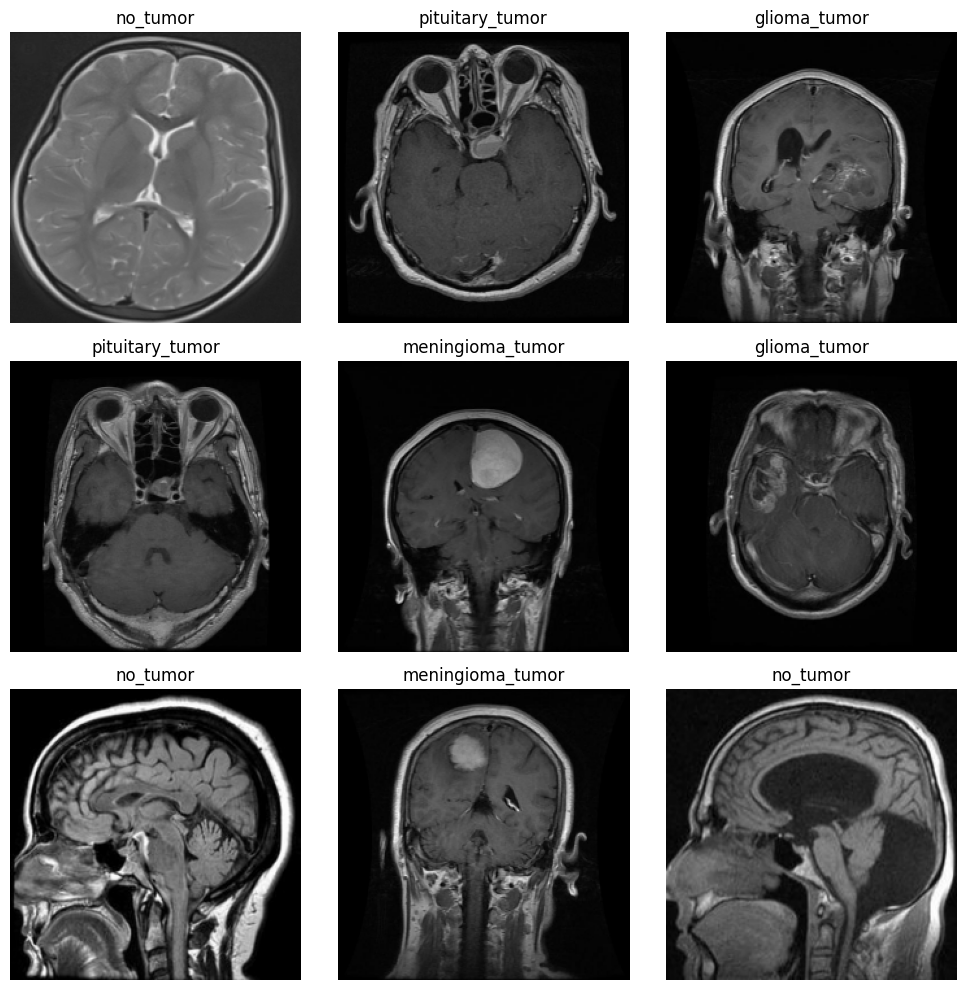

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

In [ ]:
for images, labels in train_dataset.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    print("Minimum pixel value:",
          tf.reduce_min(images).numpy())

    print("Maximum pixel value:",
          tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Task B - Implementing the Transfer Learning


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
base_model.trainable = False

In [ ]:
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(4, activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
print("Total parameters:",
      model.count_params())

print("Trainable parameters:")

for layer in model.layers:
    print(layer.name, layer.trainable)

Total parameters: 23850500
Trainable parameters:
resnet50 False
global_average_pooling2d True
dense True
dropout True
dense_1 True


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("Model compiled successfully!")

Model compiled successfully!


## Task C - Model Training and Performance Evaluation

In [ ]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 369ms/step - accuracy: 0.2944 - loss: 1.5628 - val_accuracy: 0.3240 - val_loss: 1.3121
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.3153 - loss: 1.3839 - val_accuracy: 0.3188 - val_loss: 1.2900
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.3584 - loss: 1.2970 - val_accuracy: 0.3223 - val_loss: 1.2697
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.3881 - loss: 1.2612 - val_accuracy: 0.3780 - val_loss: 1.2471
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.4203 - loss: 1.2438 - val_accuracy: 0.4390 - val_loss: 1.2271
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.4551 - loss: 1.2260 - val_accuracy: 0.4251 - val_loss: 1.2133
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.4813 - loss: 1.2012 - val_accuracy: 0.4756 - val_loss: 1.1960
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.4952 - loss: 1.1856 - val_accuracy: 0.

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
for epoch in range(EPOCHS):
    print(
        f"Epoch {epoch + 1}: "
        f"Training Accuracy = {history.history['accuracy'][epoch]:.4f}, "
        f"Validation Accuracy = {history.history['val_accuracy'][epoch]:.4f}"
    )

Epoch 1: Training Accuracy = 0.2944, Validation Accuracy = 0.3240
Epoch 2: Training Accuracy = 0.3153, Validation Accuracy = 0.3188
Epoch 3: Training Accuracy = 0.3584, Validation Accuracy = 0.3223
Epoch 4: Training Accuracy = 0.3881, Validation Accuracy = 0.3780
Epoch 5: Training Accuracy = 0.4203, Validation Accuracy = 0.4390
Epoch 6: Training Accuracy = 0.4551, Validation Accuracy = 0.4251
Epoch 7: Training Accuracy = 0.4813, Validation Accuracy = 0.4756
Epoch 8: Training Accuracy = 0.4952, Validation Accuracy = 0.4512
Epoch 9: Training Accuracy = 0.5004, Validation Accuracy = 0.4843
Epoch 10: Training Accuracy = 0.5144, Validation Accuracy = 0.4791


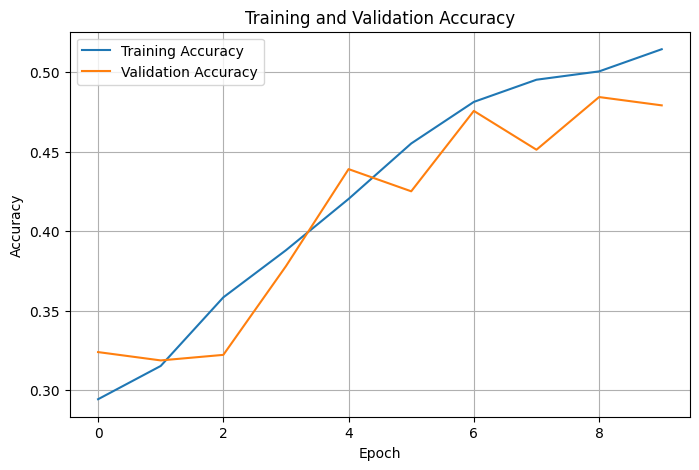

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

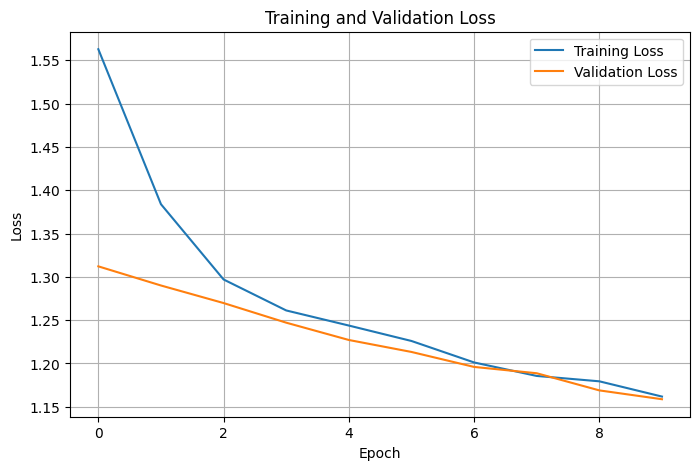

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 344ms/step - accuracy: 0.3350 - loss: 1.4672
Test Loss: 1.4672333002090454
Test Accuracy: 0.3350253701210022


In [ ]:
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 33.50%


In [ ]:
final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]

final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print("========== FINAL PERFORMANCE ==========")

print(f"Training Accuracy   : {final_train_accuracy * 100:.2f}%")
print(f"Validation Accuracy : {final_val_accuracy * 100:.2f}%")

print(f"Training Loss       : {final_train_loss:.4f}")
print(f"Validation Loss     : {final_val_loss:.4f}")

print(f"Test Accuracy       : {test_accuracy * 100:.2f}%")

========== FINAL PERFORMANCE ==========
Training Accuracy   : 51.44%
Validation Accuracy : 47.91%
Training Loss       : 1.1618
Validation Loss     : 1.1587
Test Accuracy       : 33.50%


## Task D - Using Hugging Face Pretrained Models

In [ ]:
!pip install -q transformers

In [ ]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import os

In [ ]:
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [ ]:
class_name = class_names[0]

class_folder = os.path.join(test_path, class_name)

image_name = os.listdir(class_folder)[0]

image_path = os.path.join(class_folder, image_name)

print("Image:", image_path)

Image: /content/brain_tumor/Testing/glioma_tumor/image(47).jpg


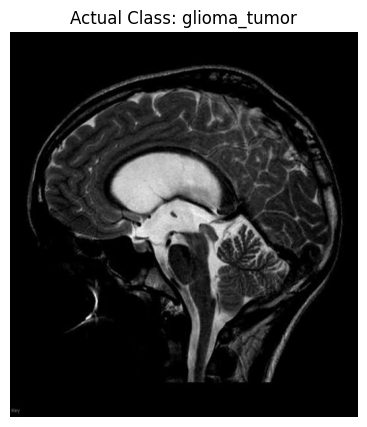

In [ ]:
image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f"Actual Class: {class_name}")
plt.axis("off")
plt.show()

In [ ]:
predictions = classifier(image)

for prediction in predictions[:5]:
    print(
        prediction["label"],
        "→",
        f"{prediction['score']:.4f}"
    )

nematode, nematode worm, roundworm → 0.0351
magpie → 0.0277
chambered nautilus, pearly nautilus, nautilus → 0.0123
nail → 0.0102
screw → 0.0101


In [ ]:
import numpy as np
import tensorflow as tf

img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

resnet_prediction = model.predict(img_array)

predicted_index = np.argmax(resnet_prediction[0])

predicted_class = class_names[predicted_index]

confidence = resnet_prediction[0][predicted_index]

print("ResNet-50 Prediction:", predicted_class)
print("Confidence:", f"{confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
ResNet-50 Prediction: no_tumor
Confidence: 0.3638


In [ ]:
print("========== MODEL COMPARISON ==========")

print("Actual Class:")
print(class_name)

print("\nResNet-50:")
print(predicted_class)

print("\nHugging Face ViT:")
print(predictions[0]["label"])

========== MODEL COMPARISON ==========
Actual Class:
glioma_tumor

ResNet-50:
no_tumor

Hugging Face ViT:
nematode, nematode worm, roundworm


In [ ]:
for class_name in class_names:

    class_folder = os.path.join(test_path, class_name)

    image_name = os.listdir(class_folder)[0]

    image_path = os.path.join(class_folder, image_name)

    image = Image.open(image_path).convert("RGB")

    hf_prediction = classifier(image)[0]["label"]

    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(prediction[0])

    resnet_prediction = class_names[predicted_index]

    print("\nActual:", class_name)
    print("ResNet-50:", resnet_prediction)
    print("Hugging Face:", hf_prediction)


Actual: glioma_tumor
ResNet-50: no_tumor
Hugging Face: nematode, nematode worm, roundworm

Actual: meningioma_tumor
ResNet-50: pituitary_tumor
Hugging Face: nematode, nematode worm, roundworm

Actual: no_tumor
ResNet-50: glioma_tumor
Hugging Face: nematode, nematode worm, roundworm

Actual: pituitary_tumor
ResNet-50: glioma_tumor
Hugging Face: nematode, nematode worm, roundworm


## Improving the ResNet model

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.
Found 2870 files belonging to 4 classes.
Using 574 files for validation.
Found 394 files belonging to 4 classes.


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [ ]:
model = models.Sequential([

    data_augmentation,

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.4),

    layers.Dense(4, activation="softmax")
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 235ms/step - accuracy: 0.5579 - loss: 1.0823 - val_accuracy: 0.7613 - val_loss: 0.6689
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step - accuracy: 0.7439 - loss: 0.6574 - val_accuracy: 0.7683 - val_loss: 0.5915
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 177ms/step - accuracy: 0.7870 - loss: 0.5534 - val_accuracy: 0.8049 - val_loss: 0.4926
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - accuracy: 0.8079 - loss: 0.4859 - val_accuracy: 0.8240 - val_loss: 0.4584
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 176ms/step - accuracy: 0.8271 - loss: 0.4503 - val_accuracy: 0.8449 - val_loss: 0.4319
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 178ms/step - accuracy: 0.8493 - loss: 0.4125 - val_accuracy: 0.8223 - val_loss: 0.4525
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - accuracy: 0.8606 - loss: 0.3821 - val_accuracy: 0.8223 - val_loss: 0.4238
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 180ms/step - accuracy: 0.8680 - loss: 0.3560 - val_accu

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.6878 - loss: 1.1780
Test Accuracy: 68.78%


In [ ]:
base_model.trainable = True

In [ ]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 287ms/step - accuracy: 0.8541 - loss: 0.3926 - val_accuracy: 0.8223 - val_loss: 0.4714
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 241ms/step - accuracy: 0.8994 - loss: 0.2598 - val_accuracy: 0.8746 - val_loss: 0.3436
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.9233 - loss: 0.2181 - val_accuracy: 0.8780 - val_loss: 0.3107
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.9342 - loss: 0.1887 - val_accuracy: 0.8815 - val_loss: 0.3044
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.9360 - loss: 0.1758 - val_accuracy: 0.8850 - val_loss: 0.2772
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.9490 - loss: 0.1503 - val_accuracy: 0.8937 - val_loss: 0.2702
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.9573 - loss: 0.1342 - val_accuracy: 0.8972 - val_loss: 0.2680
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.9608 - loss: 0.1143 - val_accu

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Fine-tuned Test Accuracy: {test_accuracy * 100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.7487 - loss: 1.3975
Fine-tuned Test Accuracy: 74.87%


In [ ]:
print("Training Accuracy:",
      history.history["accuracy"][-1])

print("Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Training Loss:",
      history.history["loss"][-1])

print("Validation Loss:",
      history.history["val_loss"][-1])

Training Accuracy: 0.9146341681480408
Validation Accuracy: 0.8449477553367615
Training Loss: 0.24140557646751404
Validation Loss: 0.3603053092956543


In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.7487 - loss: 1.3975
Test Loss: 1.3975298404693604
Test Accuracy: 0.7487309575080872
